In [1]:
import statistics
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from ast import literal_eval
import glob
from pylab import plot, show, savefig, xlim, figure, ylim, legend, boxplot, setp, axes
from lib.Attack_Evaluation_cd import Attack_Eval

In [2]:
num_layers = 3
width_layers = 80
num_gateways = 80
total_nodes = num_gateways + num_layers * width_layers
#log_dir = '/Users/claudia/PycharmProjects/MixMeasurement/Logs_adv_unrel/'
log_dir = '/Users/claudia/PycharmProjects/MixMeasurement/Logs_adv_rel/'




In [3]:
str_file_nodes = log_dir + "Adv_L3_W80_G80_A*_T*/*_nodes.csv"
list_files = [f for f in glob.glob(str_file_nodes)]

In [4]:
cost_adversaries = []
cost_targets = []

cost_adversaries_32 = []
cost_targets_32 = []
cost_adversaries_32t = []
cost_targets_32t = []



nr_nodes_offline_list = []
nr_nodes_faulty_list = []
nr_nodes_off_or_faulty_list = []
vanilla_nodes_offline_list = []
vanilla_nodes_faulty_list = []
vanilla_nodes_off_or_faulty_list = []


for file_name in list_files:
    
    df_net_nodes = pd.read_csv(str(file_name))
    dict_read_nodes = df_net_nodes.to_dict()
    dict_net_nodes = {}

    for string_id in dict_read_nodes['id']:
        dict_net_nodes[dict_read_nodes['id'][string_id]] = {}
    for g in range(num_gateways):
        dict_net_nodes[str(g)] = literal_eval(dict_read_nodes[str(0)][g])
    for layer in range(1, num_layers + 1):
        for w in range(width_layers):
            mix_id = num_gateways + (layer - 1) * width_layers + w
            dict_net_nodes[str(mix_id)] = literal_eval(dict_read_nodes[str(layer)][mix_id])
    
    cumul_adv_diff = 0
    cumul_target_diff = 0
    adversaries = [0, 0, 0, 0]
    targets = [0, 0, 0, 0]
    nr_nodes_offline = 0
    nr_nodes_faulty = 0
    nr_nodes_off_or_faulty = 0
    vanilla_nodes_offline = 0
    vanilla_nodes_faulty = 0
    vanilla_nodes_off_or_faulty = 0

    for node_id in range(320):
        if dict_net_nodes[str(node_id)]['corrupt'] == 1:
            cumul_adv_diff += 1.0 - dict_net_nodes[str(node_id)]['filter_perf_msm']
            layer = int(node_id // 80)
            adversaries[layer] += 1
        elif dict_net_nodes[str(node_id)]['target'] == 1:
            cumul_target_diff += 1.0 - dict_net_nodes[str(node_id)]['filter_perf_msm']
            layer = int(node_id // 80)
            targets[layer] += 1
        
    #if max(adversaries) <= 16 and max(targets) < 64:# and max(targets) <= 16:
    #    cost_adversaries.append(cumul_adv_diff)
    #    cost_targets.append(cumul_target_diff)
    #elif max(adversaries) < 64 and max(targets) < 64:
    #    cost_adversaries_32.append(cumul_adv_diff)
    #    cost_targets_32.append(cumul_target_diff)

    if (sum(adversaries) == 64 or sum(targets) == 64) and max(adversaries) < 64 and max(targets) < 64:# and max(targets) <= 16:
        cost_adversaries.append(cumul_adv_diff)
        cost_targets.append(cumul_target_diff)
    elif max(adversaries) < 64 and max(targets) < 64:
        cost_adversaries_32.append(cumul_adv_diff)
        cost_targets_32.append(cumul_target_diff)
    #else:
    #    cost_adversaries_32.append(cumul_adv_diff)
    #    cost_targets_32.append(cumul_target_diff)
    
    #if sum(adversaries) <= 16 and sum(targets) <= 16:
#    if max(adversaries) <= 16 and max(targets) <= 16:
#        cost_adversaries.append(cumul_adv_diff)
#        cost_targets.append(cumul_target_diff)
#    else:
#        cost_adversaries_32.append(cumul_adv_diff)
#        cost_targets_32.append(cumul_target_diff)
    #elif sum(targets) > 16:
    #    cost_adversaries_32t.append(cumul_adv_diff)
    #    cost_targets_32t.append(cumul_target_diff)
    #elif sum(adversaries) > 16:
    #    cost_adversaries_32.append(cumul_adv_diff)
    #    cost_targets_32.append(cumul_target_diff)

#    if cumul_adv_diff > 5:
        #print("----")
        #print('file:', file_name)
        #print("cumul_adv_diff=", cumul_adv_diff, "cumul_target_diff=", cumul_target_diff)
        #print("adversaries=", adversaries)
        #print("targets=", targets)

print("nr of experiments: ", len(cost_adversaries))
print("nr of experiments 32: ", len(cost_adversaries_32))
print("total: ", len(cost_adversaries)+len(cost_adversaries_32))



nr of experiments:  37
nr of experiments 32:  470
total:  507


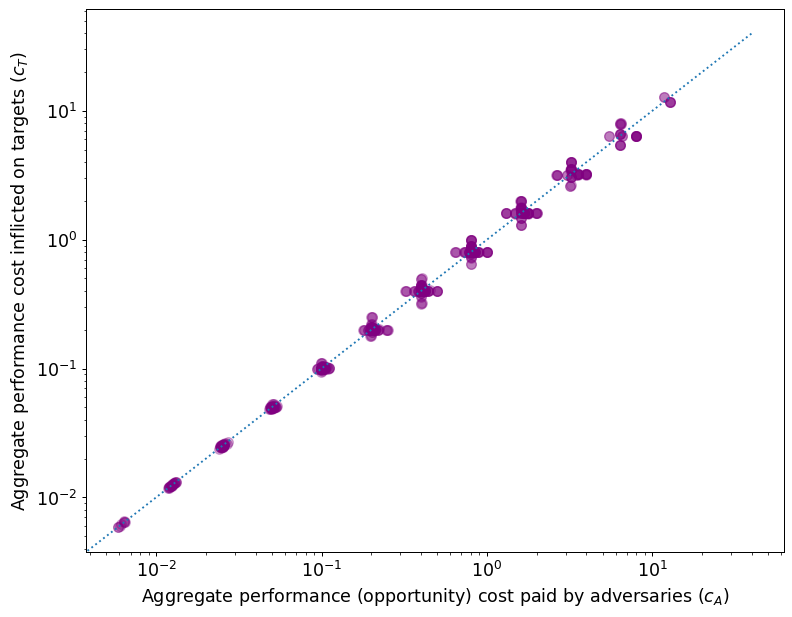

In [8]:
fig = plt.figure(figsize=(10, 8), dpi=90, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
plt.scatter(cost_adversaries, cost_targets, s=60, color="purple", alpha=0.3)
plt.scatter(cost_adversaries_32, cost_targets_32, s=60, color="purple", alpha=0.3)
#plt.scatter(cost_adversaries_32, cost_targets_32, s=100, marker="+", color="green", alpha=0.8)
#plt.scatter(cost_adversaries_32t, cost_targets_32t, s=30, marker="*", color="red", alpha=0.3)

max_val = 40
#max_val = 1.2
ax.plot([0, max_val], [0, max_val], ls=":")
#ax.set(xlim=(10**-3, max_val+0.2), ylim=(10**-3, max_val+0.2))
#ax.set(xlim=(-0.05, max_val+0.05), ylim=(-0.05, max_val+0.05))

ax.set_xlabel("Aggregate performance (opportunity) cost paid by adversaries ($c_A$)", fontsize=14)

ax.set_ylabel("Aggregate performance cost inflicted on targets ($c_T$)", fontsize=14)

ax.set_yscale('log')
ax.set_xscale('log')

plt.setp(ax.get_yticklabels(), fontsize=14)
plt.setp(ax.get_xticklabels(), fontsize=14)
plt.show()

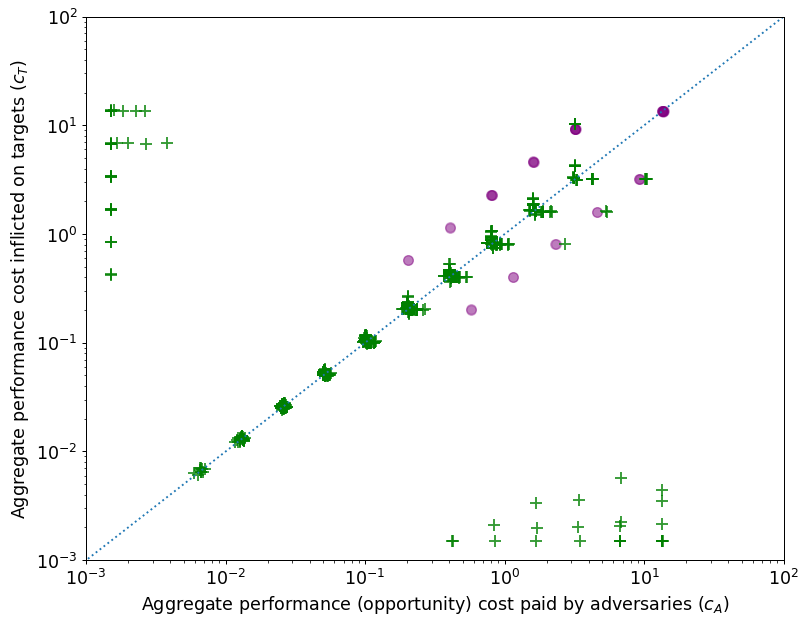

In [208]:

cost_adversaries_copy = []
cost_adversaries_32_copy = []
cost_targets_copy = []
cost_targets_32_copy = []


for i in range(len(cost_adversaries)):
    if cost_adversaries[i] < 1.5*10**-3:
        cost_adversaries_copy.append(1.5*10**-3)
    else:
        cost_adversaries_copy.append(cost_adversaries[i])

for i in range(len(cost_targets)):
    if cost_targets[i] < 1.5*10**-3:
        cost_targets_copy.append(1.5*10**-3)
    else:
        cost_targets_copy.append(cost_targets[i])

for i in range(len(cost_adversaries_32)):
    if cost_adversaries_32[i] < 1.5*10**-3:
        cost_adversaries_32_copy.append(1.5*10**-3)
    else:
        cost_adversaries_32_copy.append(cost_adversaries_32[i])

for i in range(len(cost_targets_32)):
    if cost_targets_32[i] < 1.5*10**-3:
        cost_targets_32_copy.append(1.5*10**-3)
    else:
        cost_targets_32_copy.append(cost_targets_32[i])
        
        
        
fig = plt.figure(figsize=(10, 8), dpi=90, facecolor='w', edgecolor='k')
ax = fig.add_subplot()
plt.scatter(cost_adversaries_copy, cost_targets_copy, s=60, color="purple", alpha=0.3)
plt.scatter(cost_adversaries_32_copy, cost_targets_32_copy, s=100, marker="+", color="green", alpha=0.8)
#plt.scatter(cost_adversaries_32t, cost_targets_32t, s=30, marker="*", color="red", alpha=0.3)

max_val = 100
#max_val = 1.2
ax.plot([0, max_val], [0, max_val], ls=":")
ax.set(xlim=(10**-3, max_val+0.2), ylim=(10**-3, max_val+0.2))
#ax.set(xlim=(-0.05, max_val+0.05), ylim=(-0.05, max_val+0.05))

ax.set_xlabel("Aggregate performance (opportunity) cost paid by adversaries ($c_A$)", fontsize=14)

ax.set_ylabel("Aggregate performance cost inflicted on targets ($c_T$)", fontsize=14)

ax.set_yscale('log')
ax.set_xscale('log')



plt.setp(ax.get_yticklabels(), fontsize=14)
plt.setp(ax.get_xticklabels(), fontsize=14)
plt.show()

In [594]:
file_name = "/Users/claudia/PycharmProjects/MixMeasurement/Logs/Adv_L3_W80_G80_A?????/info_nodes.csv"

df_net_nodes = pd.read_csv(str(file_name))
dict_read_nodes = df_net_nodes.to_dict()
dict_net_nodes = {}

for string_id in dict_read_nodes['id']:
    dict_net_nodes[dict_read_nodes['id'][string_id]] = {}
for g in range(num_gateways):
    dict_net_nodes[str(g)] = literal_eval(dict_read_nodes[str(0)][g])
for layer in range(1, num_layers + 1):
    for w in range(width_layers):
        mix_id = num_gateways + (layer - 1) * width_layers + w
        dict_net_nodes[str(mix_id)] = literal_eval(dict_read_nodes[str(layer)][mix_id])

for node_id in range(320):
    if dict_net_nodes[str(node_id)]['corrupt'] == 1:
        print("\n---Adversarial node", node_id)
        print("true perf=", dict_net_nodes[str(node_id)]['true_perf_all'])
        print("filtered perf=", dict_net_nodes[str(node_id)]['filter_perf_msm'])
        print("marked offine=", dict_net_nodes[str(node_id)]['marked_offline'], "med perf in", dict_net_nodes[str(node_id)]['med_perf_in_msm'])
        print("marked faulty=", dict_net_nodes[str(node_id)]['marked_faulty'], "med perf out", dict_net_nodes[str(node_id)]['med_perf_out_msm'])
    elif dict_net_nodes[str(node_id)]['target'] == 1:
        print("\n---Target node", node_id)
        print("true perf=", dict_net_nodes[str(node_id)]['true_perf_all'])
        print("filtered perf=", dict_net_nodes[str(node_id)]['filter_perf_msm'])
        print("marked offine=", dict_net_nodes[str(node_id)]['marked_offline'], "med perf in", dict_net_nodes[str(node_id)]['med_perf_in_msm'])
        print("marked faulty=", dict_net_nodes[str(node_id)]['marked_faulty'], "med perf out", dict_net_nodes[str(node_id)]['med_perf_out_msm'])

        

FileNotFoundError: [Errno 2] No such file or directory: '/Users/claudia/PycharmProjects/MixMeasurement/Logs/Adv_L3_W80_G80_A?????/info_nodes.csv'

In [ ]:

for node_id in range(80, 160):
    print("\n---Node", node_id)
    print("true perf=", dict_net_nodes[str(node_id)]['true_perf_msm'])
    print("obs perf=", dict_net_nodes[str(node_id)]['obs_perf_msm'])
    print("filtered perf=", dict_net_nodes[str(node_id)]['filter_perf_msm'])
    print("marked offine=", dict_net_nodes[str(node_id)]['marked_offline'], "med perf in", dict_net_nodes[str(node_id)]['med_perf_in_msm'])
    print("marked faulty=", dict_net_nodes[str(node_id)]['marked_faulty'], "med perf out", dict_net_nodes[str(node_id)]['med_perf_out_msm'])



In [ ]:
for node_id in range(160, 161):
    print("\n---Node", node_id)
    print("true perf=", dict_net_nodes[str(node_id)]['true_perf_all'])
    print("filtered perf=", dict_net_nodes[str(node_id)]['filter_perf_msm'])
    print("marked offine=", dict_net_nodes[str(node_id)]['marked_offline'], "med perf in", dict_net_nodes[str(node_id)]['med_perf_in_msm'])
    print("marked faulty=", dict_net_nodes[str(node_id)]['marked_faulty'], "med perf out", dict_net_nodes[str(node_id)]['med_perf_out_msm'])
    print("filter_perf_in_msm=", dict_net_nodes[str(node_id)]['filter_perf_in_msm'], "filter_perf_out_msm", dict_net_nodes[str(node_id)]['filter_perf_out_msm'])




In [50]:
file_name_links = "/Users/claudia/PycharmProjects/MixMeasurement/Logs/Adv_L3_W80_G80_A10_T1_lot1.0_m2016967_msm2016967/info_links.csv"
num_layers = 3
width_layers = 80 
num_gateways = 80 
total_bins = 1 

df_net_links = pd.read_csv(str(file_name_links))
dict_read_links = df_net_links.to_dict()
dict_net_links = {}

for string_id in dict_read_links['id']:
    dict_net_links[dict_read_links['id'][string_id]] = {}
         
for g in range(num_gateways):
    string_id = "-99_-99_" + str(g)
    dict_net_links[string_id] = literal_eval(dict_read_links['-99'][g])
    for w2 in range(width_layers):
        to_node = num_gateways + w2
        string_id = str(0) + "_" + str(g) + "_" + str(to_node)
        index = num_gateways + g*width_layers + w2 
        #print("string_id=", string_id, " ; index = ", index)
        dict_net_links[string_id] = literal_eval(dict_read_links[str(0)][index])   
        #print(str(dict_net_links[string_id]))
        
for layer in range(1, num_layers):
    for w in range(width_layers):
        from_node = num_gateways + width_layers*(layer-1) + w
        for w2 in range(width_layers):
            to_node = num_gateways + width_layers*layer + w2
            string_id = str(layer) + "_" + str(from_node) + "_" + str(to_node)
            index = num_gateways + from_node*width_layers + w2 
            #print("string_id=", string_id, " ; index=", index)
            dict_net_links[string_id] = literal_eval(dict_read_links[str(layer)][index])

for w in range(width_layers):
    from_node = num_gateways + width_layers*(num_layers-1) + w
    for g in range(num_gateways):
        string_id = str(num_layers) + "_" + str(from_node) + "_" + str(g)
        first_index = num_gateways + width_layers * (num_gateways + (num_layers-1) * width_layers)        
        index = first_index + (w * num_gateways) + g 
        #print("string_id=", string_id, " ; index = ", index)
        dict_net_links[string_id] = literal_eval(dict_read_links[str(num_layers)][index])



In [51]:
list_links = []
layer = 1
target = 160
#for pred in range(80, 160):
#    link_id = str(layer) + '_' + str(pred) + '_' + str(target)
#    list_links.append(link_id)

for suc in range(240, 320):
    link_id = str(layer+1) + '_' + str(target) + '_' + str(suc)
    list_links.append(link_id)    
    
for link_id in list_links:
    print("----\nlink id : ", link_id)
    print("Total messages in the link", dict_net_links[link_id]["total_samples_msm"])
    print("Dropped messages in the link", dict_net_links[link_id]["dropped_samples_msm"])
    print("Measured performance", dict_net_links[link_id]["measured_performance_msm"])
    print("Drops assigned predecessor", dict_net_links[link_id]["drops_assigned_pred_msm"])
    print("Drops assigned successor", dict_net_links[link_id]["drops_assigned_suc_msm"])
    print("Anomaly", dict_net_links[link_id]["anomaly"])
    print("Layer overload", dict_net_links[link_id]["layer_overload"])



----
link id :  2_160_240
Total messages in the link [564]
Dropped messages in the link [564]
Measured performance [0.0]
Drops assigned predecessor [282.0]
Drops assigned successor [282.0]
Anomaly [1]
Layer overload [0]
----
link id :  2_160_241
Total messages in the link [588]
Dropped messages in the link [588]
Measured performance [0.0]
Drops assigned predecessor [294.0]
Drops assigned successor [294.0]
Anomaly [1]
Layer overload [0]
----
link id :  2_160_242
Total messages in the link [575]
Dropped messages in the link [575]
Measured performance [0.0]
Drops assigned predecessor [287.5]
Drops assigned successor [287.5]
Anomaly [1]
Layer overload [0]
----
link id :  2_160_243
Total messages in the link [598]
Dropped messages in the link [598]
Measured performance [0.0]
Drops assigned predecessor [299.0]
Drops assigned successor [299.0]
Anomaly [1]
Layer overload [0]
----
link id :  2_160_244
Total messages in the link [587]
Dropped messages in the link [587]
Measured performance [0.0]

In [ ]:
        if dict_net_nodes[str(node_id)]['marked_offline'][0] == 1: 
            nr_nodes_offline += 1
            nr_nodes_off_or_faulty += 1
            if dict_net_nodes[str(node_id)]['marked_faulty'][0] == 1:
                nr_nodes_faulty += 1
            if dict_net_nodes[str(node_id)]['corrupt'] == 0 and dict_net_nodes[str(node_id)]['target'] == 0:
                vanilla_nodes_offline += 1
                vanilla_nodes_off_or_faulty += 1
                if dict_net_nodes[str(node_id)]['marked_faulty'][0] == 1:
                    vanilla_nodes_faulty += 1
        elif dict_net_nodes[str(node_id)]['marked_faulty'][0] == 1: 
            nr_nodes_faulty += 1
            nr_nodes_off_or_faulty += 1
            if dict_net_nodes[str(node_id)]['corrupt'] == 0 and dict_net_nodes[str(node_id)]['target'] == 0:
                vanilla_nodes_faulty += 1
                vanilla_nodes_off_or_faulty += 1
                print("node_id faulty:", node_id)
                print(dict_net_nodes[str(node_id)]['filter_perf_out_msm'])

    nr_nodes_offline_list.append(nr_nodes_offline)
    nr_nodes_faulty_list.append(nr_nodes_faulty)
    nr_nodes_off_or_faulty_list.append(nr_nodes_off_or_faulty)
    vanilla_nodes_offline_list.append(vanilla_nodes_offline)
    vanilla_nodes_faulty_list.append(vanilla_nodes_faulty)
    vanilla_nodes_off_or_faulty_list.append(vanilla_nodes_off_or_faulty)